
🖼️ Diagrama 'figura 1.png' recebido. Iniciando análise...


---

### 🖼️ Diagrama de Arquitetura Enviado:

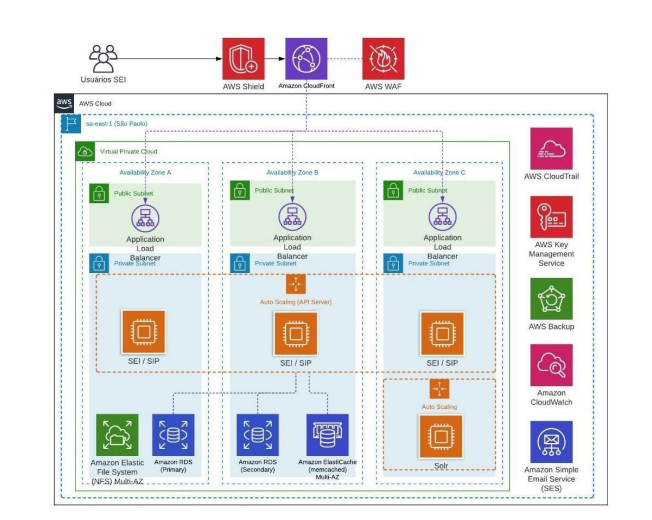


🤖 Analisando o diagrama de arquitetura com GPT-4o...
👍 Análise de ameaças concluída com sucesso!


### 🛡️ Análise de Ameaças (Threat Modeling) - STRIDE

Para realizar uma análise de ameaças usando o modelo STRIDE no diagrama de arquitetura fornecido, podemos categorizar as ameaças em Spoofing (falsificação), Tampering (adulteração), Repudiation (repúdio), Information Disclosure (divulgação de informações), Denial of Service (negação de serviço) e Elevation of Privilege (elevação de privilégios). Vamos analisar os principais componentes e fluxos de dados:

### 1. Usuários -> AWS Shield/Amazon CloudFront/AWS WAF

- **Spoofing**: Usuários podem falsificar sua identidade.
  - *Mitigação*: Autenticação robusta (2FA, autenticação baseada em tokens).

- **Tampering**: Manipulação de dados em trânsito.
  - *Mitigação*: Usar HTTPS/TLS para proteger a integridade e confidencialidade dos dados.

- **Repudiation**: Usuários negam transações ou acessos.
  - *Mitigação*: Logs detalhados e assinaturas digitais.

- **Information Disclosure**: Vazamento de dados sensíveis.
  - *Mitigação*: Criptografia de dados em trânsito.

- **Denial of Service**: Bombardeio de requisições para indisponibilizar o serviço.
  - *Mitigação*: Implementação do AWS Shield para mitigação DDoS.

- **Elevation of Privilege**: Acesso não autorizado a recursos.
  - *Mitigação*: Controle de acesso baseado em papéis (RBAC).

### 2. AWS WAF -> VPC (Load Balancer)

- **Spoofing**: Falsificação de identidade de origem.
  - *Mitigação*: Regras de segurança no WAF.

- **Tampering**: Alteração de pacotes de entrada.
  - *Mitigação*: Inspeção de pacotes e validação.

- **Repudiation**: Falta de evidência de transações.
  - *Mitigação*: Monitoramento e registros (CloudTrail).

- **Information Disclosure**: Vazamento de dados internos.
  - *Mitigação*: Firewall adicional e criptografia.

- **Denial of Service**: Ataques de serviço no balancer.
  - *Mitigação*: Escalabilidade automática e limitações de taxa.

- **Elevation of Privilege**: Acesso elevado indevido.
  - *Mitigação*: Permissões restritas no IAM.

### 3. Load Balancer -> Servidores de Aplicação

- **Spoofing**: Falsificação de identidades do servidor.
  - *Mitigação*: Autenticação mútua TLS.

- **Tampering**: Injeção de pacotes maliciosos.
  - *Mitigação*: Verificação de integridade e inspeção de tráfego.

- **Repudiation**: Ações não rastreáveis.
  - *Mitigação*: Logs centralizados com AWS CloudTrail.

- **Information Disclosure**: Exposição de dados de aplicação.
  - *Mitigação*: Criptografia em trânsito e segurança em camadas.

- **Denial of Service**: Sobrecarga de servidores.
  - *Mitigação*: Balanceamento de carga efetivo e alertas de uso.

- **Elevation of Privilege**: Escalação de privilégios pelo servidor.
  - *Mitigação*: Controle de acesso rigoroso e isolamento de processos.

### 4. Servidores -> Amazonas RDS/Elasticache

- **Spoofing**: Falsificação de origem do cliente.
  - *Mitigação*: VPC com regras de segurança.

- **Tampering**: Modificação de dados nas bases.
  - *Mitigação*: Criptografia em repouso e backups regulares.

- **Repudiation**: Alterações não rastreáveis no banco de dados.
  - *Mitigação*: Auditoria de banco de dados.

- **Information Disclosure**: Vazamento de informações confidenciais.
  - *Mitigação*: Controle de acesso e criptografia de dados.

- **Denial of Service**: Sobrecarga de requisições ao BD.
  - *Mitigação*: Escalabilidade automática e limites de conexão.

- **Elevation of Privilege**: Acesso administrativo ao BD.
  - *Mitigação*: Gerenciamento de credenciais e permissões.

### 5. AWS Cloud Services (CloudTrail, KMS, etc.)

- **Spoofing**: Falsificação de acesso a serviços.
  - *Mitigação*: Autenticação e autorização robustas.

- **Tampering**: Alteração de logs ou configurações.
  - *Mitigação*: Controle de acesso e auditorias regulares.

- **Repudiation**: Negação de ações administrativas.
  - *Mitigação*: Registros detalhados e imutáveis.

- **Information Disclosure**: Exposição de dados de configuração.
  - *Mitigação*: Acesso restrito e criptografia.

- **Denial of Service**: Interrupção de serviços AWS críticos.
  - *Mitigação*: Planejamento de capacidade e redundância.

- **Elevation of Privilege**: Acesso não autorizado a serviços.
  - *Mitigação*: Revisão de políticas IAM e monitoramento contínuo.

Cada componente e fluxo deve ser avaliado e protegido adequadamente, considerando potenciais vetores de ataque e aplicando as melhores práticas de segurança.


📄 Gerando relatório em PDF...
✅ Relatório salvo como 'Relatorio_Analise_Ameacas_STRIDE.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Instalação das dependências
# Adicionamos a biblioteca fpdf para gerar relatórios em PDF
!pip install openai ipywidgets fpdf &> /dev/null
print("✅ Bibliotecas instaladas com sucesso (openai, ipywidgets, fpdf)!")

# 2. Importações e Configurações
import os
import base64
from openai import OpenAI
from getpass import getpass
import ipywidgets as widgets
from google.colab import files
from IPython.display import display, Markdown, Image
from fpdf import FPDF
import datetime

# 3. Configuração da Chave da API OpenAI
try:
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        api_key = getpass('🔑 Por favor, insira sua chave da API da OpenAI e pressione Enter: ')
        os.environ['OPENAI_API_KEY'] = api_key

    client = OpenAI(api_key=api_key)
    print("✅ Chave da API da OpenAI configurada.")
except Exception as e:
    print(f"❌ Ocorreu um erro ao configurar a chave: {e}")

# 4. Função de Análise de Imagem com GPT-4o (sem alterações)
def analyze_image_with_gpt4o(image_path, prompt):
    print("\n🤖 Analisando o diagrama de arquitetura com GPT-4o...")
    try:
        with open(image_path, "rb") as image_file:
            base64_image = base64.b64encode(image_file.read()).decode('utf-8')
    except FileNotFoundError:
        return "❌ Erro: Arquivo de imagem não encontrado."

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}, {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}]}],
            max_tokens=2000
        )
        print("👍 Análise de ameaças concluída com sucesso!")
        return response.choices[0].message.content
    except Exception as e:
        return f"❌ Erro ao chamar a API da OpenAI: {e}"

# --- NOVO: Função para Gerar Relatório em PDF ---
def create_pdf_report(analysis_text, image_path):
    """
    Cria um relatório em PDF com a análise STRIDE e a imagem do diagrama.
    """
    print("\n📄 Gerando relatório em PDF...")
    pdf = FPDF()
    pdf.add_page()

    # Título do Relatório
    pdf.set_font("Arial", 'B', 16)
    pdf.cell(0, 10, 'Relatório de Análise de Ameaças (Threat Modeling)', 0, 1, 'C')
    pdf.ln(5)

    # Data da Análise
    pdf.set_font("Arial", '', 10)
    today = datetime.date.today().strftime("%d/%m/%Y")
    pdf.cell(0, 5, f'Data da Análise: {today}', 0, 1, 'R')
    pdf.ln(10)

    # Imagem do Diagrama
    pdf.set_font("Arial", 'B', 12)
    pdf.cell(0, 10, '1. Diagrama de Arquitetura Analisado', 0, 1)
    pdf.image(image_path, x=pdf.get_x() + 10, w=pdf.w - 40)
    pdf.ln(5)
    pdf.add_page() # Nova página para a análise

    # Análise STRIDE
    pdf.set_font("Arial", 'B', 12)
    pdf.cell(0, 10, '2. Análise de Ameaças (Modelo STRIDE)', 0, 1)
    pdf.set_font("Arial", '', 11)
    # Adiciona o texto da análise, tratando caracteres especiais
    # A função 'latin-1' é usada para evitar erros com caracteres não-ASCII
    pdf.multi_cell(0, 5, analysis_text.encode('latin-1', 'replace').decode('latin-1'))

    report_filename = "Relatorio_Analise_Ameacas_STRIDE.pdf"
    pdf.output(report_filename)
    print(f"✅ Relatório salvo como '{report_filename}'")
    return report_filename

# 5. Interface Interativa com Prompt Especializado para STRIDE
uploader = widgets.FileUpload(accept='image/*', multiple=False, description='Enviar Diagrama')
stride_prompt = "Você é um especialista em cibersegurança realizando uma análise de ameaças (threat modeling). Analise o diagrama de arquitetura de sistema fornecido usando o modelo STRIDE. Para cada componente e fluxo de dados principal, identifique potenciais ameaças em cada categoria (Spoofing, Tampering, Repudiation, Information Disclosure, Denial of Service, Elevation of Privilege). Apresente sua análise de forma estruturada, listando os componentes, as ameaças STRIDE associadas e possíveis mitigações."
prompt_input = widgets.Textarea(value=stride_prompt, description='Prompt:', layout=widgets.Layout(width='90%', height='200px'))

def on_upload_change(change):
    if not change.new: return
    from IPython.display import clear_output
    clear_output(wait=True)
    display(widgets.VBox([prompt_input, uploader]))

    # Adaptação para ipywidgets no Colab (v7)
    # change.new é um dict no formato: {'nome_arquivo.png': {'content': b'...', 'metadata': {...}}}

    # Obtém o nome do arquivo (primeira chave do dicionário)
    try:
        image_name = next(iter(change.new))
        file_info = change.new[image_name]
        content = file_info['content']
    except Exception as e:
        # Fallback para tentar acessar como objeto se a estrutura for diferente
        print(f"⚠️ Tentando método alternativo de leitura devido a: {e}")
        uploaded_file = list(change.new.values())[0]
        image_name = uploaded_file.get('name', 'diagrama_upload.png')
        content = uploaded_file.get('content')

    with open(image_name, 'wb') as f:
        f.write(content)

    print(f"\n🖼️ Diagrama '{image_name}' recebido. Iniciando análise...")

    display(Markdown("---"))
    display(Markdown("### 🖼️ Diagrama de Arquitetura Enviado:"))
    display(Image(image_name, width=600))

    analysis_result = analyze_image_with_gpt4o(image_name, prompt_input.value)

    display(Markdown("### 🛡️ Análise de Ameaças (Threat Modeling) - STRIDE"))
    display(Markdown(analysis_result))

    # --- NOVO: Geração e Download do PDF ---
    if not analysis_result.startswith("❌"):
        report_file = create_pdf_report(analysis_result, image_name)
        # Oferece o arquivo para download no Colab
        files.download(report_file)

uploader.observe(on_upload_change, names='value')

# Exibe as instruções e a interface
display(Markdown("### Projeto do Hackathon: Análise de Ameaças com GPT-4o e STRIDE"))
display(Markdown("**PASSO 1:** Insira sua chave da API da OpenAI (se solicitado)."))
display(Markdown("**PASSO 2:** Revise o prompt de análise STRIDE (ajuste se necessário)."))
display(Markdown("**PASSO 3:** Envie um diagrama de arquitetura para iniciar a análise."))
display(Markdown("Após a análise, um relatório em PDF será gerado e o download iniciado automaticamente."))

app_layout = widgets.VBox([prompt_input, uploader])
display(app_layout)